In [75]:
import os
import torch
from PIL import Image
import my_models_mae
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [93]:
from typing import Any, Literal

import numpy as np
import numpy.typing as npt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import ElasticNet, LogisticRegression
from sklearn.metrics import f1_score  # pyright: ignore [reportUnknownVariableType]
from sklearn.metrics import (
    mean_squared_error,  # pyright: ignore [reportUnknownVariableType]
)
from sklearn.metrics import (
    precision_recall_curve,  # pyright: ignore [reportUnknownVariableType]
)
from sklearn.metrics import (
    precision_score,  # pyright: ignore [reportUnknownVariableType]
)
from sklearn.metrics import recall_score  # pyright: ignore [reportUnknownVariableType]
from sklearn.metrics import roc_auc_score  # pyright: ignore [reportUnknownVariableType]
from sklearn.metrics import (
    root_mean_squared_error,  # pyright: ignore [reportUnknownVariableType]
)
from sklearn.metrics import (
    accuracy_score,
    auc,
    brier_score_loss,
    confusion_matrix,
    mean_absolute_error,
    r2_score,
)
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.exceptions import ConvergenceWarning
import h5py

import warnings

warnings.filterwarnings("ignore", category=ConvergenceWarning)


def get_metrics(
    labels: npt.NDArray[Any], probas: npt.NDArray[Any], preds: npt.NDArray[Any]
):
    assert (
        len(labels) == len(probas) == len(preds)
    ), f"{len(labels)}, {len(probas)}, {len(preds)}"
    metrics: dict[str, float | list[int] | list[float]] = {}
    metrics["support"] = len(labels)
    metrics["support_per_class"] = np.unique(labels, return_counts=True)[
        1
    ].tolist()  # pyright: ignore
    metrics["accuracy"] = float(accuracy_score(labels, preds))
    metrics["precision"] = float(
        precision_score(labels, preds, average="macro")  # pyright: ignore
    )
    metrics["precision_per_class"] = precision_score(
        labels, preds, average=None
    ).tolist()  # pyright: ignore
    metrics["recall"] = float(
        recall_score(labels, preds, average="macro")  # pyright: ignore
    )
    metrics["recall_per_class"] = recall_score(
        labels, preds, average=None
    ).tolist()  # pyright: ignore
    metrics["f1"] = float(f1_score(labels, preds, average="macro"))  # pyright: ignore
    metrics["f1_per_class"] = f1_score(
        labels, preds, average=None
    ).tolist()  # pyright: ignore
    if np.unique(labels)[-1] == 1:  # binary classification
        metrics["precision_binary_pos"] = float(
            precision_score(labels, preds)  # pyright: ignore
        )
        metrics["recall_binary_pos"] = float(
            recall_score(labels, preds)  # pyright: ignore
        )
        metrics["f1_binary_pos"] = float(f1_score(labels, preds))  # pyright: ignore
        # works only in binary case
        precision, recall, _ = precision_recall_curve(  # pyright: ignore
            labels, probas[:, 1]
        )
        metrics["pr_auc_binary"] = float(auc(recall, precision))  # pyright: ignore
        metrics["roc_auc"] = float(
            roc_auc_score(labels, probas[:, 1], average="macro")
        )  # pyright: ignore
    else:
        metrics["roc_auc"] = float(
            roc_auc_score(labels, probas, average="macro", multi_class="ovo")
        )  # pyright: ignore
    cm = confusion_matrix(labels, preds)  # pyright: ignore
    metrics["confusion_matrix"] = cm.tolist()  # pyright: ignore
    fp = cm.sum(axis=0) - np.diag(cm)  # pyright: ignore
    fn = cm.sum(axis=1) - np.diag(cm)  # pyright: ignore
    tp = np.diag(cm)  # pyright: ignore
    tn = cm.sum() - (fp + fn + tp)
    metrics["fp"] = fp.tolist()
    metrics["fn"] = fn.tolist()
    metrics["tp"] = tp.tolist()
    metrics["tn"] = tn.tolist()
    metrics["brier_inv"] = 1 - float(
        brier_score_loss(labels, probas, scale_by_half=True)  # pyright: ignore
    )
    brier_per_class: list[float] = []
    for label in np.unique(labels):
        mask = labels == label
        brier_per_class.append(
            1
            - float(
                brier_score_loss(  # pyright: ignore
                    np.ones_like(labels[mask]),
                    probas[mask, label],
                    scale_by_half=True,  # pyright: ignore
                )
            )
        )
    metrics["brier_inv_per_class"] = brier_per_class
    return metrics


def evaluate_by_classifier_probe(
    clf: LogisticRegression | RandomForestClassifier,
    embeddings: Any,
    labels: Any,
    train_idcs: Any | None = None,
    test_idcs: Any | None = None,
):
    if train_idcs is None or test_idcs is None:
        # should be fixed in numpy 1.25
        train_idcs = np.arange(  # pyright: ignore [reportUnknownMemberType]
            len(embeddings)
        )
        test_idcs = np.arange(  # pyright: ignore [reportUnknownMemberType]
            len(embeddings)
        )
    clf = clf.fit(embeddings[train_idcs], labels[train_idcs])  # pyright: ignore
    clf_probas: npt.NDArray[np.float32] = clf.predict_proba(  # pyright: ignore
        embeddings[test_idcs]
    )
    clf_preds: npt.NDArray[np.float32] = clf.predict(  # pyright: ignore
        embeddings[test_idcs]
    )
    return clf, clf_probas, clf_preds


def summarize(metrics: list[dict[str, float | list[int | float]]]):
    summary_dict: dict[str, float | list[int | float | list[int] | list[float]]] = {}
    for key in metrics[0].keys():
        d = np.array([m[key] for m in metrics])
        summary_dict[key] = d.tolist()
        summary_dict[key + "_mean"] = d.mean(axis=0).tolist()
        summary_dict[key + "_std"] = d.std(axis=0).tolist()
        if key == "confusion_matrix":
            summary_dict[key + "_sum"] = np.sum(
                [m[key] for m in metrics], axis=0
            ).tolist()
    return summary_dict


def plot_confusion_matrix(
    confusion_matrix: npt.NDArray[Any],
    display_labels: list[str],
    im_kw: dict[str, Any] = {},
    vmax: int | None = 300,
    title: str = "Confusion matrix",
    show: bool = False,
    save_path: str | None = None,
    plt_style: Literal["dark_background", "default"] = "default",
):
    plt.style.use(plt_style)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix, display_labels=display_labels
    )
    disp.plot(im_kw=im_kw)
    if vmax is not None:
        disp.ax_.get_images()[0].set_clim(0, vmax)
    plt.title(title)  # type: ignore
    plt.tight_layout()
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)  # type: ignore
    if show:
        plt.show()  # type: ignore
    else:
        plt.close()


def plot_three_confusion_matrices(
    confusion_matrices: list[npt.NDArray[Any]],
    display_labels: list[str],
    im_kw: dict[str, Any] = {},
        vmax: int | None = 300,
    show: bool = False,
    save_path: str | None = None,
    plt_style: Literal["dark_background", "default"] = "default",
):
    plt.style.use(plt_style)
    fig, axes = plt.subplots(
        1, len(confusion_matrices), figsize=(6.5 * len(confusion_matrices), 5)
    )
    for i, cm in enumerate(confusion_matrices):
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm, display_labels=display_labels
        )
        disp.plot(im_kw=im_kw, ax=axes[i])  # type: ignore
        if vmax is not None:
            disp.ax_.get_images()[0].set_clim(0, vmax)
        axes[i].set_title(f"Image class {i}")  # type: ignore
    plt.suptitle("Confusion matrices")  # type: ignore
    plt.tight_layout()
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)  # type: ignore
    if show:
        plt.show()  # type: ignore
    else:
        plt.close()


def plot_images_grid(
    images: npt.NDArray[Any],
    title: str = "Images grid",
):
    n_cols = 6
    n_rows = np.ceil(len(images) / n_cols).astype(int)
    figsize = (n_cols * 3, n_rows * 3)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes_flat = axes.flatten()
    for i in range(n_rows):
        for j in range(n_cols):
            idx = i * n_cols + j
            if idx < len(images):
                axes_flat[idx].imshow(
                    images[idx], cmap="gray", vmin=-0.7378069, vmax=2.8465295
                )
            axes_flat[idx].axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_imgs_with_patches_hoghlighted(
    imgs, patch_idxs_to_highlight, title, patch_color="red"
):
    fig, axes = plt.subplots(1, len(imgs), figsize=(5 * len(imgs), 5))
    for i, img in enumerate(imgs):
        axes[i].imshow(img, cmap="gray", vmin=-0.7378069, vmax=2.8465295)
        axes[i].set_title(f"Image class {i}")
        for patch_idx in patch_idxs_to_highlight[i]:
            row = patch_idx // 14
            col = patch_idx % 14
            rect = plt.Rectangle(
                (col * 16, row * 16),
                16,
                16,
                edgecolor=patch_color,
                facecolor="none",
                linewidth=1.5,
            )
            axes[i].add_patch(rect)
        # axes[i].axis("off")
    plt.suptitle(title)
    plt.show()


def load_patch_labels_from_h5py():
    p = "/g/kreshuk/hellgoth/projects/ML4ExM_project/ML4ExM/experiments/spheres_small_conext_contrastive/4uqsmnsh/predictions/best_otherVols/preds_best.hdf5"
    with h5py.File(p, "r") as f:
        patch_labels = f["patch_labels"][:]
        dataset_idxs = f["dataset_idxs_per_patch"][:]
    p = "/scratch/hellgoth/data/spheres_small_2d/spheres_small_2d_patchROIs_patch-16-16_contains_cell.hdf5"
    with h5py.File(p, "r") as f:
        is_cell = f["contains_cell"]
        is_cell_val = np.concatenate(
            [
                is_cell[700 * 196 : 1000 * 196],
                is_cell[1700 * 196 : 2000 * 196],
                is_cell[2700 * 196 : 3000 * 196],
            ]
        )
    return patch_labels, dataset_idxs, is_cell_val

In [77]:
patch_labels, dataset_idxs_per_patch, is_cell = load_patch_labels_from_h5py()
print(patch_labels.shape, dataset_idxs_per_patch.shape, patch_labels.min(), patch_labels.max())
patch_labels_cell = patch_labels[is_cell]
dataset_idxs_per_patch_cell = dataset_idxs_per_patch[is_cell]
print(patch_labels_cell.shape, dataset_idxs_per_patch_cell.shape, patch_labels_cell.min(), patch_labels_cell.max())

(176400,) (176400,) 0 3
(78870,) (78870,) 0 3


In [78]:
transform_train = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=0.17597473, std=0.23851053),
    ]
)

# CHANGED loader
def pil_loader_grey(path: str) -> Image:
    return Image.open(path)

dataset_val = datasets.ImageFolder(
    os.path.join("/scratch/hellgoth/data/spheres_small_2d_png/", "val"),
    loader=pil_loader_grey,
    transform=transform_train,
)
sample = dataset_val[0][0]
sample.shape, sample.min(), sample.max(), len(dataset_val)

(torch.Size([1, 224, 224]), tensor(-0.7378), tensor(1.5641), 900)

In [79]:
m = my_models_mae.__dict__["mae_vit_base_patch16"](
        norm_pix_loss=False,
        in_chans=1,
        loss_on_all_patches=False,
        pos_encode_w=1.0,
    )
patches = []
for img, _ in dataset_val:
    patches.append(m.patchify(img[None]).reshape(1, 196, 16, 16).squeeze())
patches = np.concatenate(patches)
patches_cell = patches[is_cell]
print(patches.shape, patches_cell.shape)

(176400, 16, 16) (78870, 16, 16)


In [80]:
# normal MAE, single channel, no norm pix loss

In [94]:
p = "/g/kreshuk/hellgoth/projects/ML4ExM_project/mae/spheres_maester6/checkpoint-799.pth"
ckpt = torch.load(p, map_location="cpu")
model = my_models_mae.__dict__["mae_vit_base_patch16"](
        norm_pix_loss=False,
        in_chans=1,
        loss_on_all_patches=False,
        pos_encode_w=1.0,
    )
model.load_state_dict(ckpt["model"])

<All keys matched successfully>

In [95]:
embeddings = np.zeros((len(dataset_val), 196, 768))
cls_embeddings = np.zeros((len(dataset_val), 768))
for i, sample in enumerate(tqdm(dataset_val)):  # sample is (image, label)
    latent, mask, ids_restore = model.forward_encoder(sample[0][None], 0.0)
    embeddings[i] = latent[0, 1:].detach().cpu().numpy()  # rmv cls token
    cls_embeddings[i] = latent[0, 0].detach().cpu().numpy()
embeddings.shape, cls_embeddings.shape

100%|██████████| 900/900 [00:46<00:00, 19.26it/s]


((900, 196, 768), (900, 768))

In [96]:
embeddings_cell = embeddings.reshape(-1, embeddings.shape[-1])[is_cell]
embeddings_cell.shape

(78870, 768)

[0.4539844925911045, 0.4038092767747135, 0.1048205517727803, 0.08833159515898231]


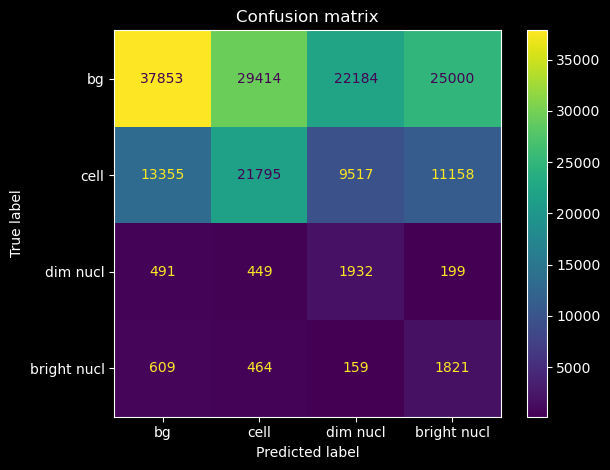

In [91]:
# patch level accum
embeds = embeddings.reshape(-1, embeddings.shape[-1])
preds = np.zeros((embeds.shape[0],))
probas = np.zeros((embeds.shape[0], 4))
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, patch_labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=patch_labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    probas[test_idcs] = clf_probas
    preds[test_idcs] = clf_preds
metrics = get_metrics(
    labels=patch_labels, probas=probas, preds=preds
)
print(metrics["f1_per_class"])
cm = confusion_matrix(patch_labels, preds)
plot_confusion_matrix(
    confusion_matrix=cm,
    display_labels=("bg", "cell", "dim nucl", "bright nucl"),
    # vmax=900*196*0.75,
    vmax=None,
    plt_style="dark_background",
    show=True,
)

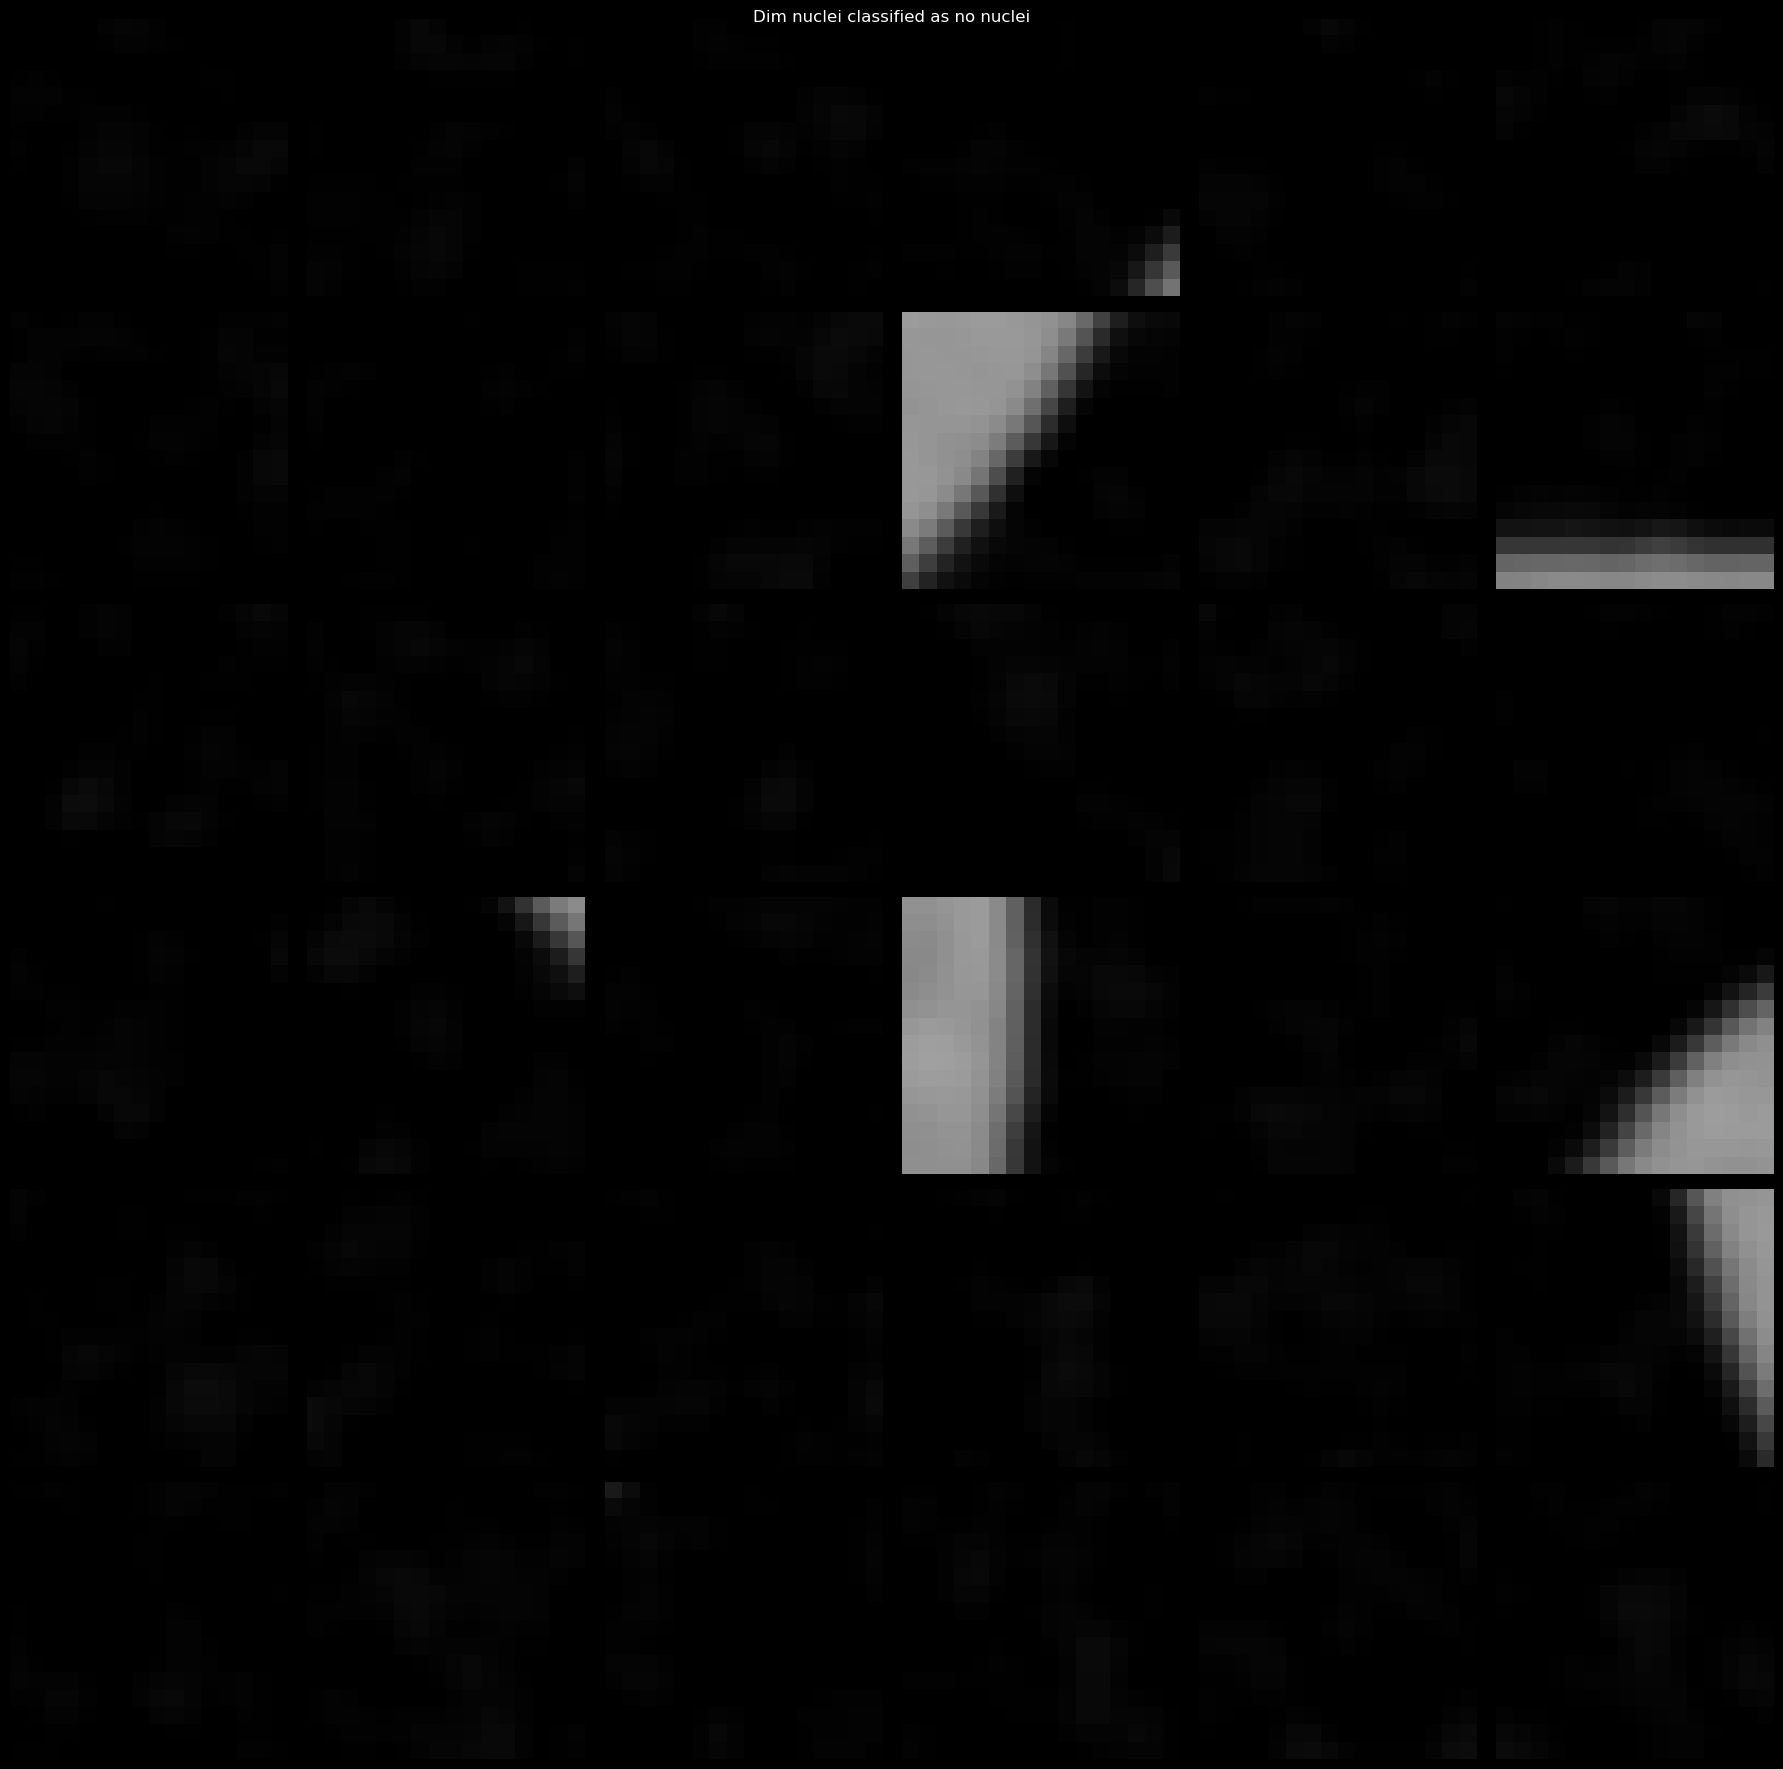

In [85]:
# dim but considered as no nucl
n = 36
idcs = np.random.choice(
    np.where((patch_labels == 0) & (preds == 1))[0], size=n, replace=False
)
plot_images_grid(
    images=np.array([patches[i] for i in idcs]),
    title="Dim nuclei classified as no nuclei",
)

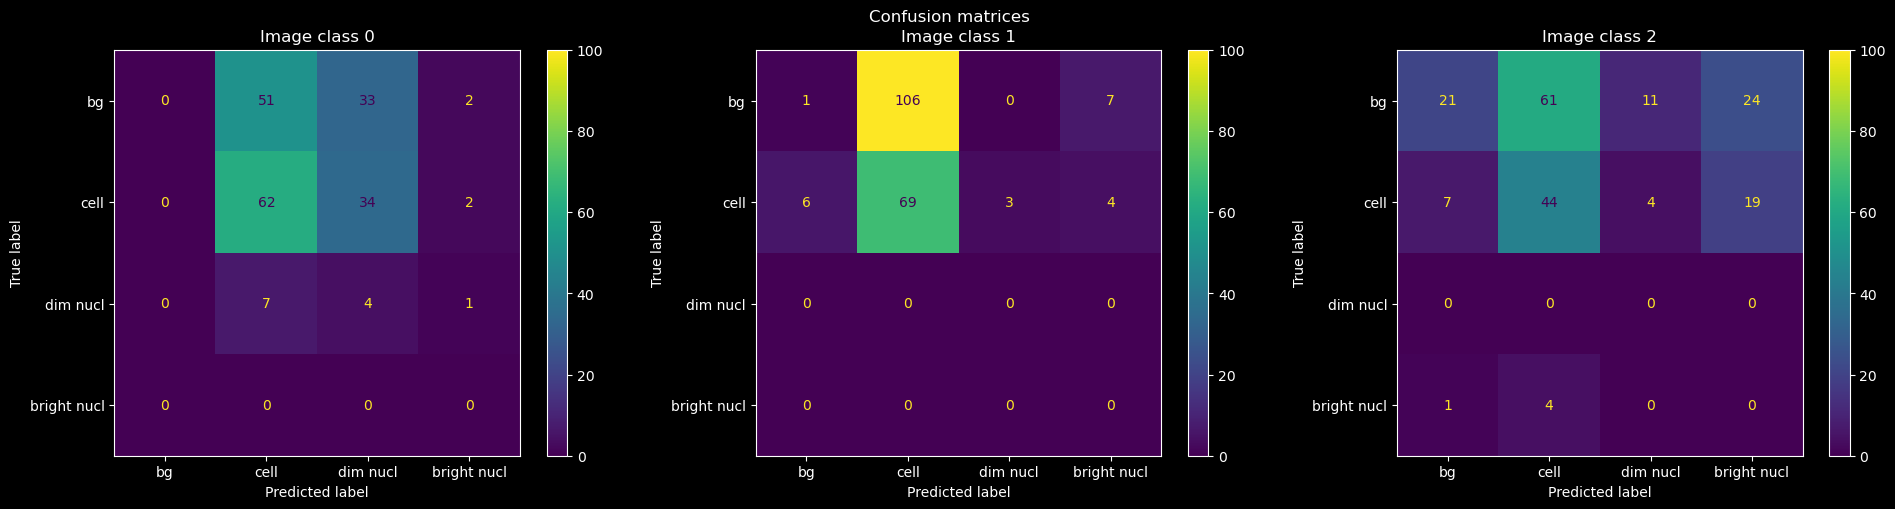

In [97]:
# plot cm for one image per class separately
img_idxs = [0, 300, 600]
cms = [confusion_matrix(patch_labels[img_idx*196:(img_idx+1)*196], preds[img_idx*196:(img_idx+1)*196]) for img_idx in img_idxs]
plot_three_confusion_matrices(
    confusion_matrices=cms,
    display_labels=("bg", "cell", "dim nucl", "bright nucl"),
    vmax=100,
    plt_style="dark_background",
    show=True,
)

[0.22128280770049572, 0.4911156494197351, 0.2132407636994793, 0.1820164914270756]


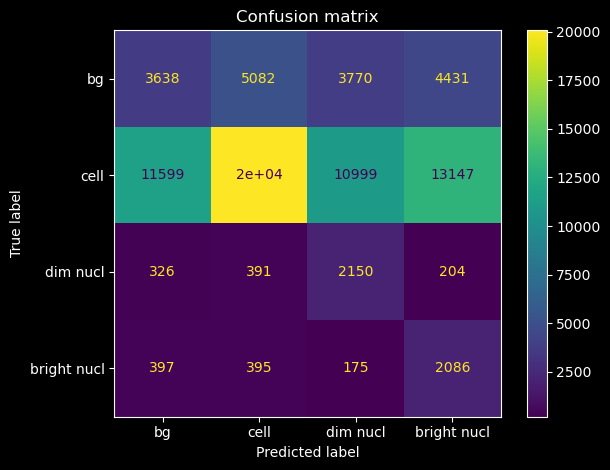

In [86]:
# patch level accum, cell only
embeds = embeddings_cell
preds = np.zeros((embeds.shape[0],))
probas = np.zeros((embeds.shape[0], 4))
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, patch_labels_cell)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=patch_labels_cell,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    probas[test_idcs] = clf_probas
    preds[test_idcs] = clf_preds
metrics = get_metrics(
    labels=patch_labels_cell, probas=probas, preds=preds
)
print(metrics["f1_per_class"])
cm = confusion_matrix(patch_labels_cell, preds)
plot_confusion_matrix(
    confusion_matrix=cm,
    display_labels=("bg", "cell", "dim nucl", "bright nucl"),
    # vmax=900*196*0.75,
    vmax=None,
    plt_style="dark_background",
    show=True,
)

True class: bg


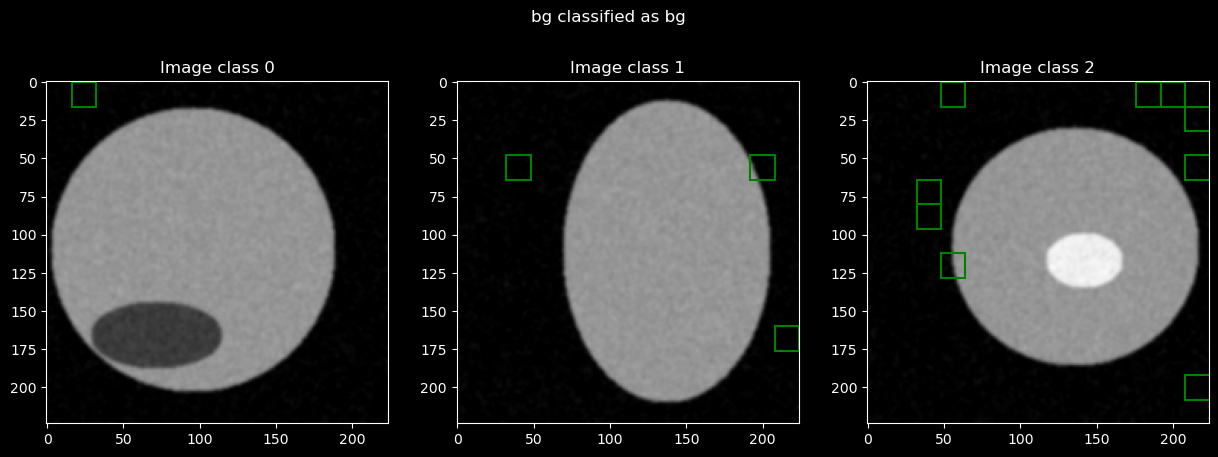

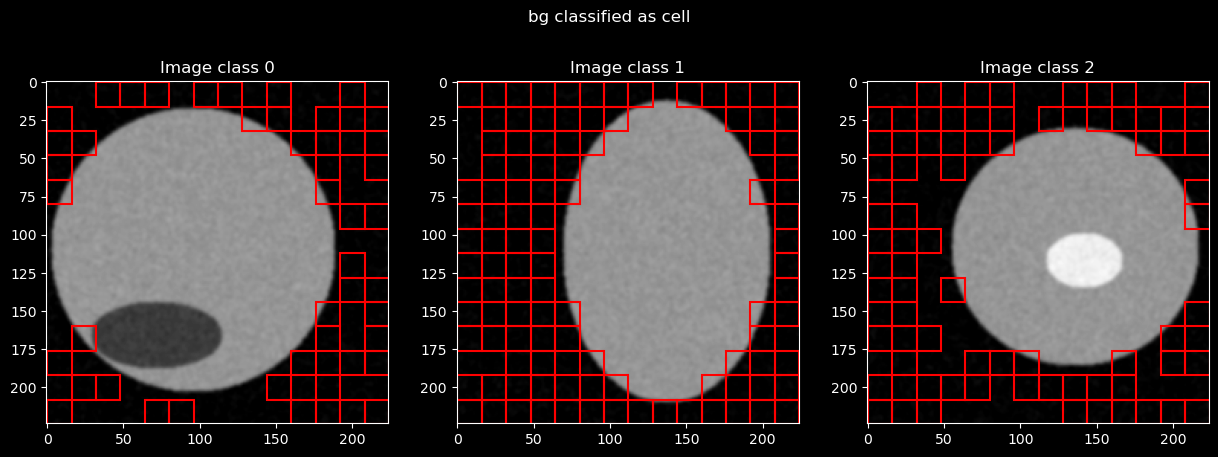

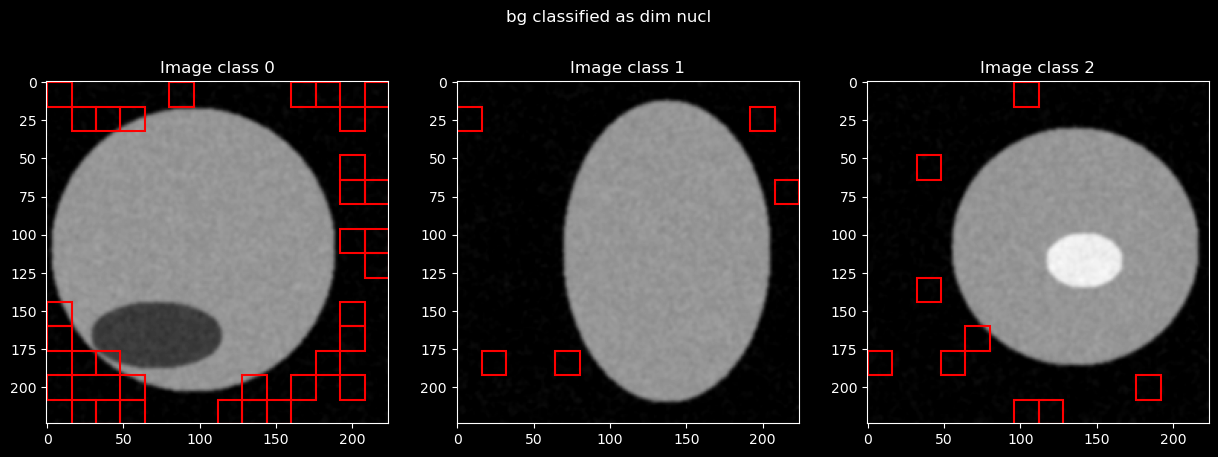

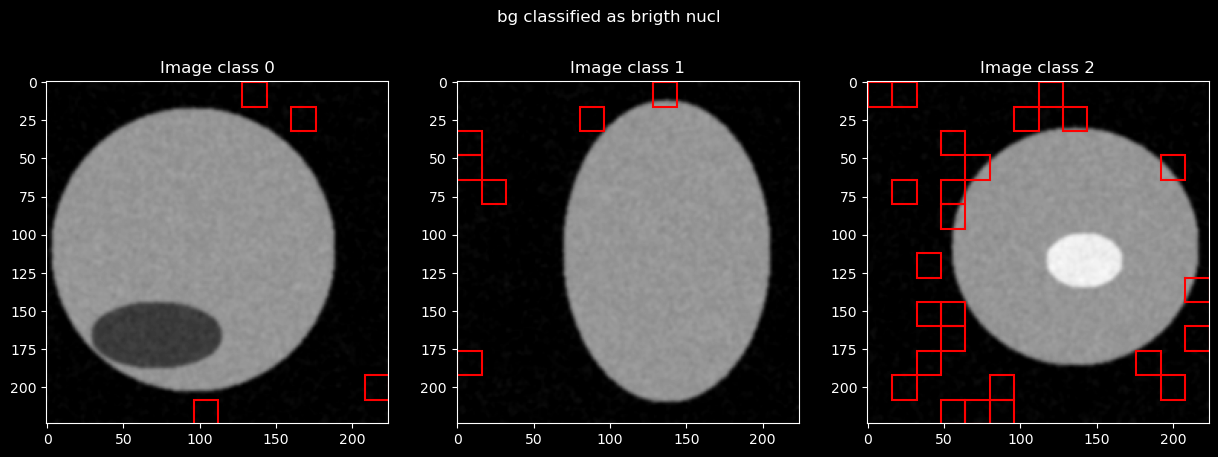

True class: cell


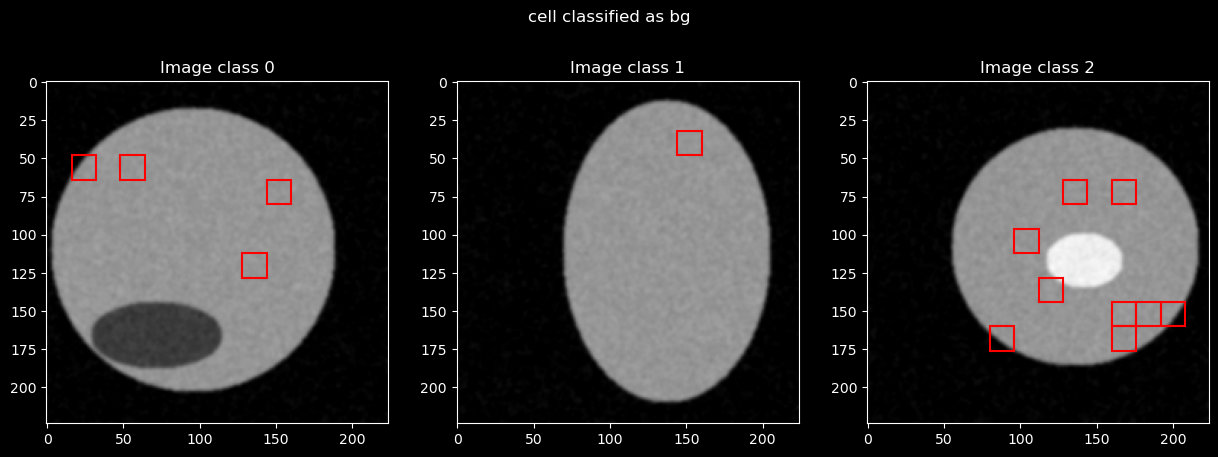

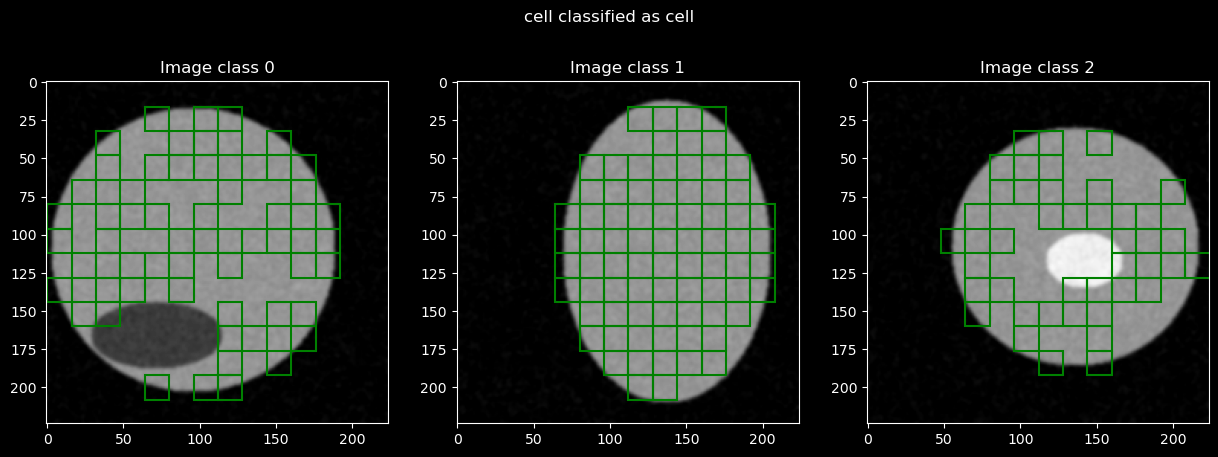

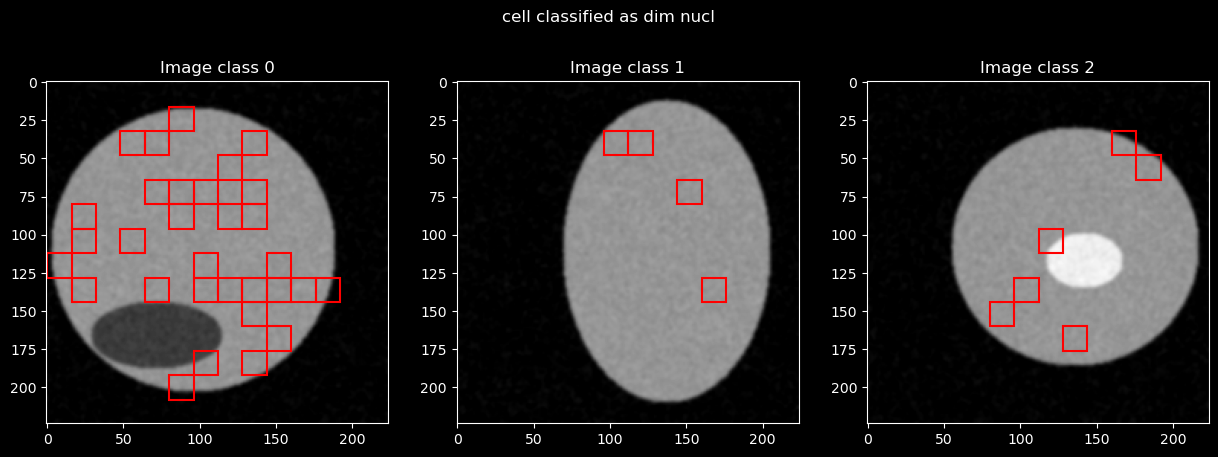

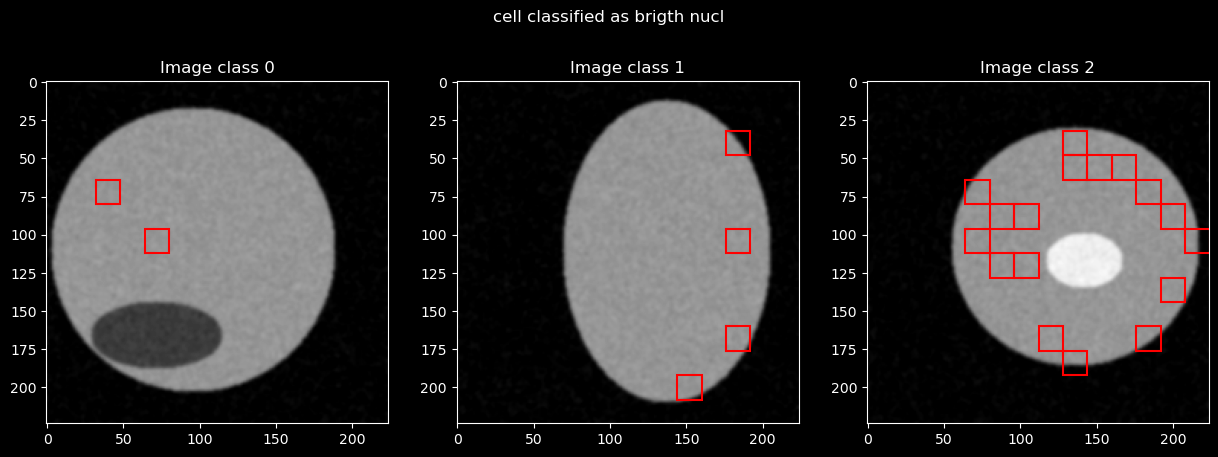

True class: dim nucl


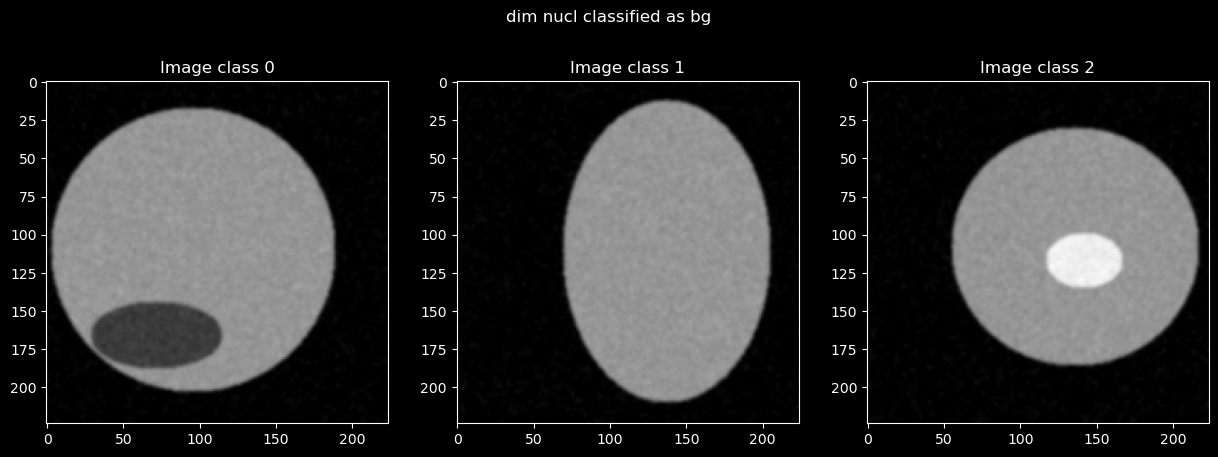

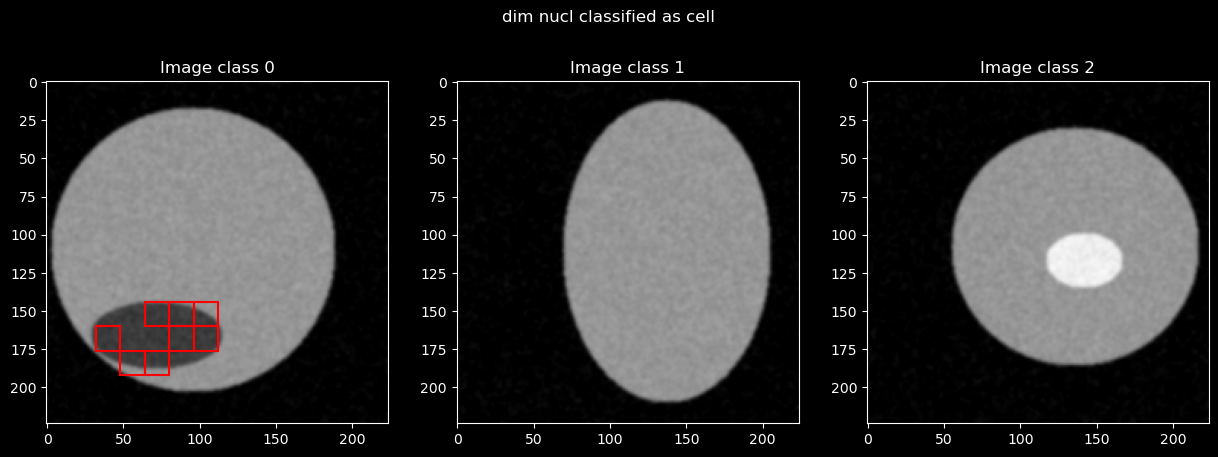

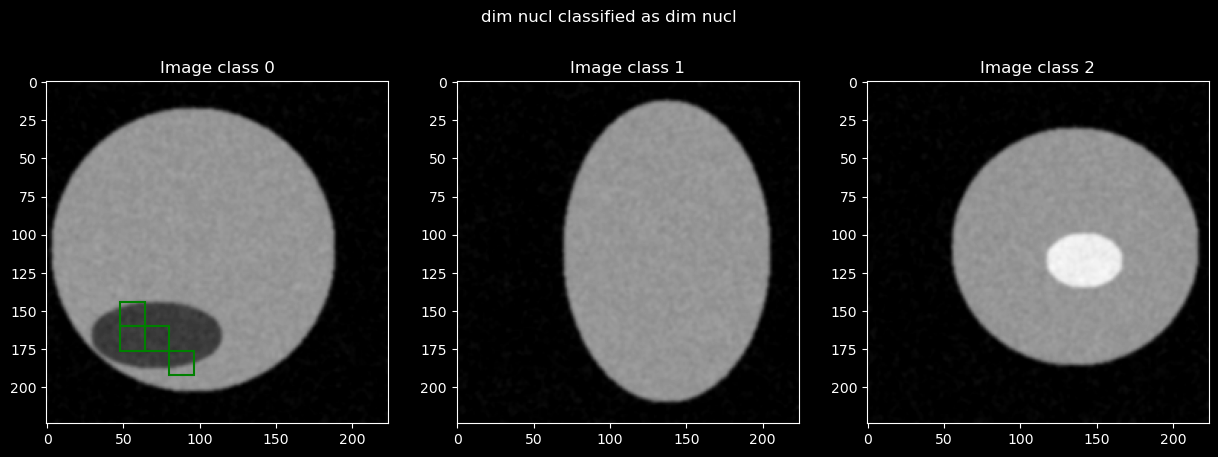

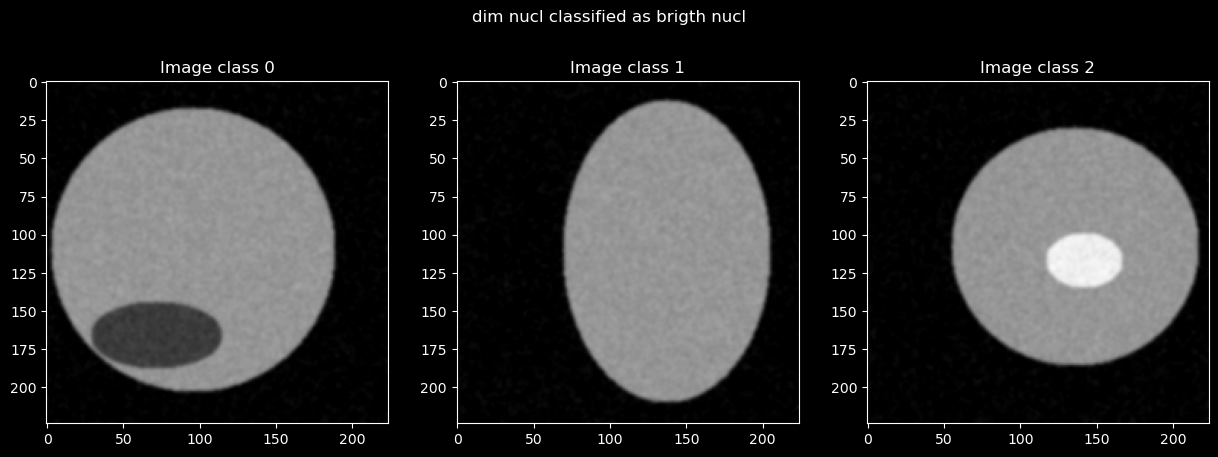

True class: brigth nucl


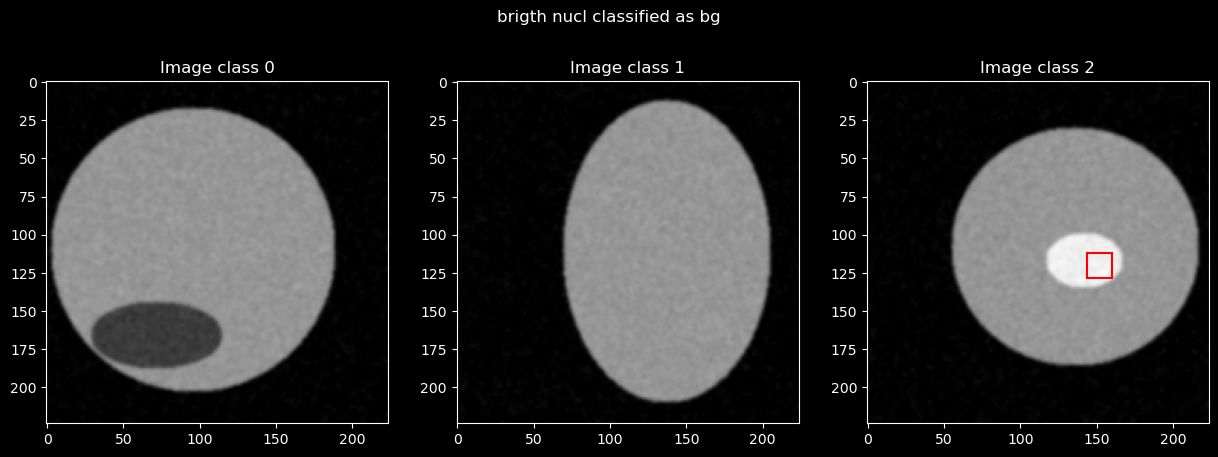

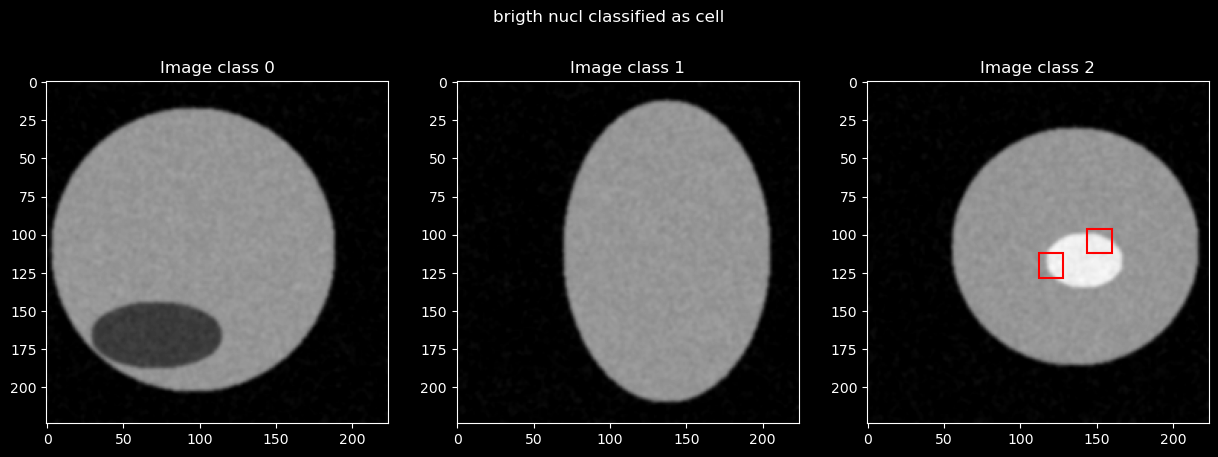

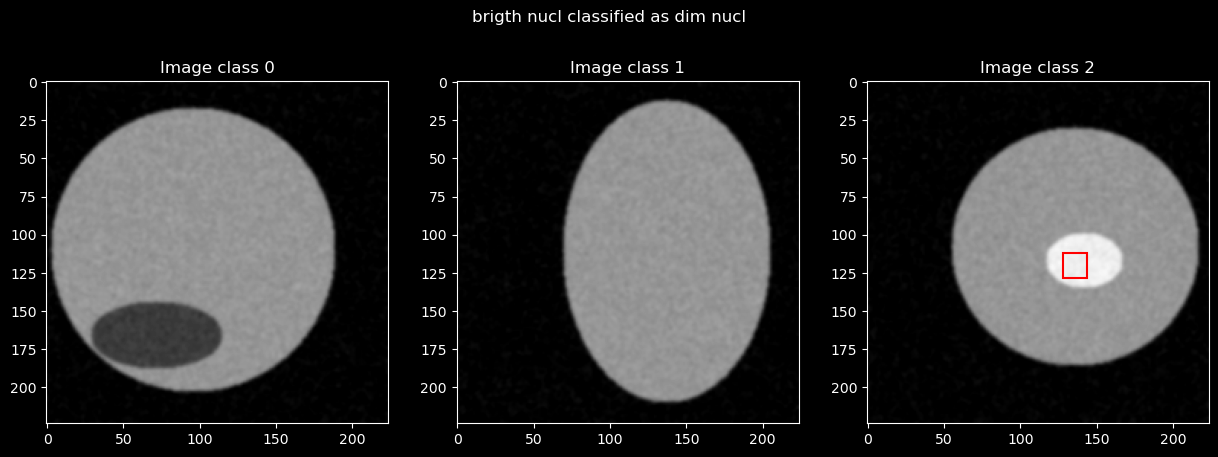

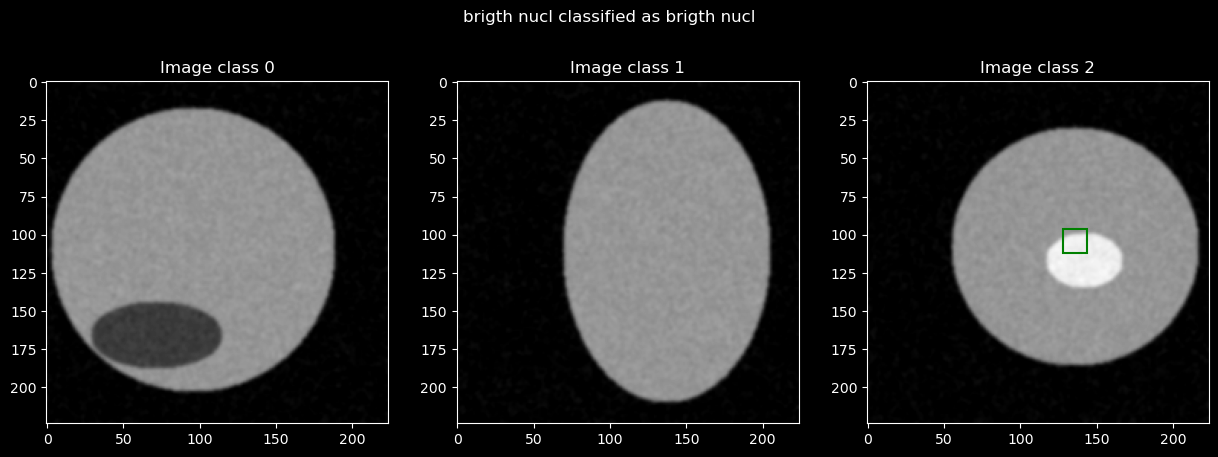

In [ ]:
class_names = ["bg", "cell", "dim nucl", "brigth nucl"]
img_idxs = [0, 300, 600]
imgs = [dataset_val[i][0].numpy().squeeze() for i in img_idxs]
for true_c in range(4):
    print(f"True class: {class_names[true_c]}")
    for pred_c in range(4):
        patch_idxs_to_highlight = []
        for img_idx in img_idxs:
            patch_idxs = np.where(
                (patch_labels[img_idx * 196 : (img_idx + 1) * 196] == true_c)
                & (preds[img_idx * 196 : (img_idx + 1) * 196] == pred_c)
            )[0]
            patch_idxs_to_highlight.append(patch_idxs)
        plot_imgs_with_patches_hoghlighted(
            imgs,
            patch_idxs_to_highlight,
            title=f"{class_names[true_c]} classified as {class_names[pred_c]}",
            patch_color="green" if true_c == pred_c else "red",
        )

In [ ]:
# normal MAE, single channel, no norm pix loss, loss on all patches

In [ ]:
p = "/g/kreshuk/hellgoth/projects/ML4ExM_project/mae/spheres_maester7/checkpoint-799.pth"
ckpt = torch.load(p, map_location="cpu")
model = my_models_mae.__dict__["mae_vit_base_patch16"](
        norm_pix_loss=False,
        in_chans=1,
        loss_on_all_patches=True,
        pos_encode_w=1.0,
    )
model.load_state_dict(ckpt["model"])

<All keys matched successfully>

In [ ]:
embeddings = np.zeros((len(dataset_val), 196, 768))
cls_embeddings = np.zeros((len(dataset_val), 768))
for i, sample in enumerate(tqdm(dataset_val)):  # sample is (image, label)
    latent, mask, ids_restore = model.forward_encoder(sample[0][None], 0.0)
    embeddings[i] = latent[0, 1:].detach().cpu().numpy()  # rmv cls token
    cls_embeddings[i] = latent[0, 0].detach().cpu().numpy()
embeddings.shape, cls_embeddings.shape

100%|██████████| 900/900 [00:48<00:00, 18.38it/s]


((900, 196, 768), (900, 768))

In [ ]:
embeddings_cell = embeddings.reshape(-1, embeddings.shape[-1])[is_cell]
embeddings_cell.shape

(78870, 768)

[0.4273402345767046, 0.4007589992999521, 0.11838102603763857, 0.10937573065232639]


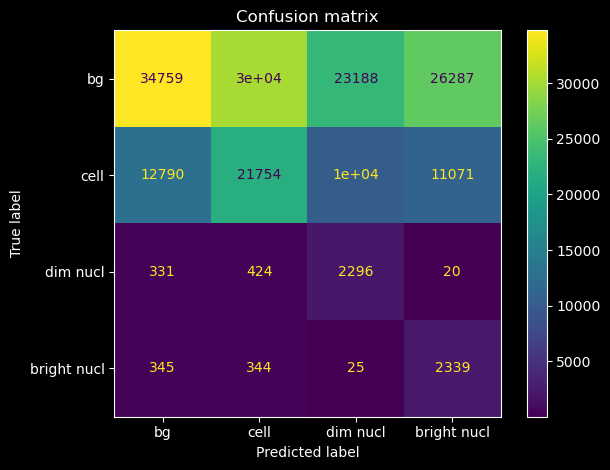

In [ ]:
# patch level accum
embeds = embeddings.reshape(-1, embeddings.shape[-1])
preds = np.zeros((embeds.shape[0],))
probas = np.zeros((embeds.shape[0], 4))
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, patch_labels)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=patch_labels,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    probas[test_idcs] = clf_probas
    preds[test_idcs] = clf_preds
metrics = get_metrics(
    labels=patch_labels, probas=probas, preds=preds
)
print(metrics["f1_per_class"])
cm = confusion_matrix(patch_labels, preds)
plot_confusion_matrix(
    confusion_matrix=cm,
    display_labels=("bg", "cell", "dim nucl", "bright nucl"),
    # vmax=900*196*0.75,
    vmax=None,
    plt_style="dark_background",
    show=True,
)

[0.22550639495746894, 0.5246546920386508, 0.23833614390106803, 0.22871736662883088]


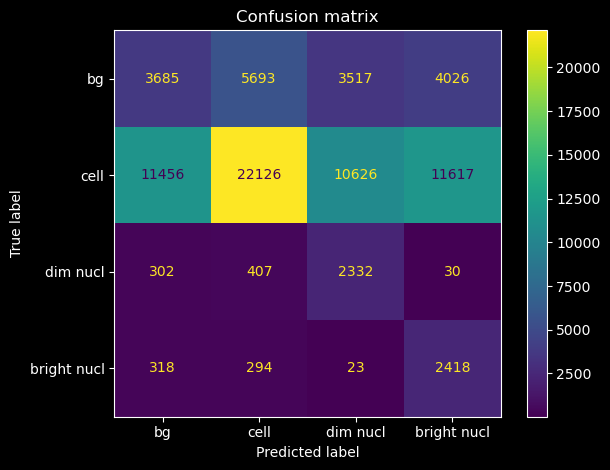

In [ ]:
# patch level accum, cell only
embeds = embeddings_cell
preds = np.zeros((embeds.shape[0],))
probas = np.zeros((embeds.shape[0], 4))
k_folds = 3
metrics: list[dict[str, float | list[int] | list[float]]] = []
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=0)
for i, (train_idcs, test_idcs) in enumerate(
    kf.split(embeds, patch_labels_cell)  # pyright: ignore [reportUnknownMemberType]
):
    _, clf_probas, clf_preds = evaluate_by_classifier_probe(
        clf=LogisticRegression(
            random_state=0,
            class_weight="balanced",
        ),
        embeddings=embeds,  # pyright: ignore [reportArgumentType]
        labels=patch_labels_cell,
        train_idcs=train_idcs,
        test_idcs=test_idcs,
    )
    probas[test_idcs] = clf_probas
    preds[test_idcs] = clf_preds
metrics = get_metrics(
    labels=patch_labels_cell, probas=probas, preds=preds
)
print(metrics["f1_per_class"])
cm = confusion_matrix(patch_labels_cell, preds)
plot_confusion_matrix(
    confusion_matrix=cm,
    display_labels=("bg", "cell", "dim nucl", "bright nucl"),
    # vmax=900*196*0.75,
    vmax=None,
    plt_style="dark_background",
    show=True,
)